In [123]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization, Add
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import xgboost as xgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib
%matplotlib inline
route_imp = 'best_model_gpa_imp.keras'

In [124]:
df_test = pd.read_csv("dataset/teen_test_clean.csv")
df_test.head(3)

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,total_digital_load,sleep_quality_ratio,mental_health_risk,lifestyle_balance,gender_male,platform_usage_Instagram,platform_usage_TikTok,target_academic_performance
0,1.490790,-0.416878,-0.852495,-5.199338,1.008673,1.283458,0.882057,-0.545846,-0.904702,-0.967422,0.825830,-0.335333,1.276036,0,1,0,3.68
1,-0.469701,0.764710,-0.544847,0.389414,1.275817,-1.195656,0.540753,-0.896825,0.149746,0.967422,-0.817331,-0.126937,-0.491846,1,0,1,3.44
2,1.000667,-0.834427,-0.126937,-0.458679,1.008673,-1.195656,-1.165766,1.209050,-0.201737,-1.120205,0.425007,-0.126937,0.515705,0,1,0,3.05


In [125]:
df_train = pd.read_csv("dataset/teen_train_clean.csv")
df_train.head(3)

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,total_digital_load,sleep_quality_ratio,mental_health_risk,lifestyle_balance,gender_male,platform_usage_Instagram,platform_usage_TikTok,target_academic_performance
0,0.020422,0.595113,0.967422,-0.362241,0.834427,-1.195656,1.564665,-1.598783,-0.553219,0.444660,0.911804,-0.335333,-0.568987,0,1,0,3.27
1,-0.469701,0.430727,0.589456,0.731217,0.389414,0.043901,1.564665,1.560029,-1.256185,0.698526,-0.222135,1.073988,-0.045799,0,1,0,2.84
2,-1.449946,-2.322575,0.335333,0.050661,-0.282216,1.283458,-0.141854,-0.194867,1.555678,-1.639976,0.195841,0.650837,2.104585,1,0,1,2.55


In [126]:
y_test_arr = df_test['target_academic_performance'].values
y_test = df_test['target_academic_performance']
df_test = df_test.drop(columns=['target_academic_performance'])
X_test_arr = df_test.values
X_test = df_test.copy()
y_test.head()

0    3.68
1    3.44
2    3.05
3    3.56
4    2.16
Name: target_academic_performance, dtype: float64

In [127]:
X_test.head()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,total_digital_load,sleep_quality_ratio,mental_health_risk,lifestyle_balance,gender_male,platform_usage_Instagram,platform_usage_TikTok
0,1.490790,-0.416878,-0.852495,-5.199338,1.008673,1.283458,0.882057,-0.545846,-0.904702,-0.967422,0.825830,-0.335333,1.276036,0,1,0
1,-0.469701,0.764710,-0.544847,0.389414,1.275817,-1.195656,0.540753,-0.896825,0.149746,0.967422,-0.817331,-0.126937,-0.491846,1,0,1
2,1.000667,-0.834427,-0.126937,-0.458679,1.008673,-1.195656,-1.165766,1.209050,-0.201737,-1.120205,0.425007,-0.126937,0.515705,0,1,0
3,-1.449946,-0.834427,-0.501298,-1.746017,0.834427,0.043901,-0.483158,0.858071,0.501229,-1.549706,0.985263,0.458679,1.181661,0,1,0
4,-1.449946,1.247754,-1.746017,-0.458679,-0.012660,1.283458,-0.483158,-0.194867,-1.256185,0.967422,-0.732499,-1.029957,0.042070,1,0,0


In [128]:
y_train_arr = df_train['target_academic_performance'].values
y_train = df_train['target_academic_performance']
df_train = df_train.drop(columns=['target_academic_performance'])
X_train_arr = df_train.values
X_train = df_train.copy()
y_train.head()

0    3.27
1    2.84
2    2.55
3    2.54
4    3.81
Name: target_academic_performance, dtype: float64

In [129]:
X_train.head()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,total_digital_load,sleep_quality_ratio,mental_health_risk,lifestyle_balance,gender_male,platform_usage_Instagram,platform_usage_TikTok
0,0.020422,0.595113,0.967422,-0.362241,0.834427,-1.195656,1.564665,-1.598783,-0.553219,0.444660,0.911804,-0.335333,-0.568987,0,1,0
1,-0.469701,0.430727,0.589456,0.731217,0.389414,0.043901,1.564665,1.560029,-1.256185,0.698526,-0.222135,1.073988,-0.045799,0,1,0
2,-1.449946,-2.322575,0.335333,0.050661,-0.282216,1.283458,-0.141854,-0.194867,1.555678,-1.639976,0.195841,0.650837,2.104585,1,0,1
3,0.020422,0.282216,-1.508944,-0.242903,-1.008673,1.283458,0.540753,0.507092,1.555678,0.165327,-0.835846,1.508944,0.062132,0,0,1
4,-0.959824,0.698526,-0.242903,-0.698526,-0.165327,0.043901,0.882057,-1.247804,-0.904702,0.444660,0.531471,-0.698526,-0.409231,0,1,0


In [130]:
BATCH_SIZE = 16

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train.values, test_size=0.15
)

train_pipeline = tf.data.Dataset.from_tensor_slices((X_train_final, y_train_final))
train_pipeline = train_pipeline.shuffle(buffer_size=len(X_train_final)).batch(BATCH_SIZE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test.to_numpy(), y_test.to_numpy())).batch(BATCH_SIZE)

In [131]:
input_shape_dim = X_train_final.shape[1]

# 1. Definimos la capa de entrada
inputs = tf.keras.layers.Input(shape=(input_shape_dim,))

# 2. Primera transformación (Capas ocultas)
x = tf.keras.layers.Dense(64, activation='swish')(inputs)
x = tf.keras.layers.Dropout(0.3)(x)

# Para poder sumar la entrada original a la salida, deben tener el mismo tamaño.
# Proyectamos la entrada original al tamaño 32
entrada_proyectada = tf.keras.layers.Dense(32, activation='linear')(x)

x = tf.keras.layers.Dense(32, activation='swish')(x)
x = tf.keras.layers.Dropout(0.3)(x)

# 3. ¡LA CONEXIÓN RESIDUAL! Sumamos la transformación con la entrada original
x_residual = tf.keras.layers.Add()([x, entrada_proyectada])

# 4. Capa de salida
outputs = tf.keras.layers.Dense(1, activation='linear')(x_residual)

# 5. Creamos el modelo
model_imp = tf.keras.Model(inputs=inputs, outputs=outputs)

model_imp.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 16)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 64)        │      1,088 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 64)        │          0 │ dense_24[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 32)        │      2,080 │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 32)        │          0 │ dense_26[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 32)        │      2,080 │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 32)        │          0 │ dropout_13[0][0], │
│                     │                   │            │ dense_25[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 1)         │         33 │ add_6[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,281 (20.63 KB)

 Trainable params: 5,281 (20.63 KB)

 Non-trainable params: 0 (0.00 B)

In [132]:
checkpoint_callback_imp = ModelCheckpoint(
    filepath=route_imp,       
    monitor='val_mae',         
    save_best_only=True,        
    mode='min',                 
    verbose=1                   
)
early_stop = EarlyStopping(
    monitor='val_mae', 
    patience=16, 
    restore_best_weights=True
)
lr_reducer = ReduceLROnPlateau(
    monitor='val_mae', 
    factor=0.2,  
    patience=5,      
    min_lr=1e-5,     
    verbose=1
)

In [133]:
optimizer = tf.keras.optimizers.AdamW(learning_rate=0.001, weight_decay=1e-4)

model_imp.compile(
    optimizer=optimizer,             
    loss='mse',                   
    metrics=['mae', tf.keras.metrics.RootMeanSquaredError(name='rmse')]       
)

In [134]:
history_imp = model_imp.fit(
    train_pipeline,
    epochs=100, 
    validation_data=val_dataset,
    callbacks=[checkpoint_callback_imp, lr_reducer, early_stop],
    verbose=1)

Epoch 1/100
45/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.8446 - mae: 2.1541 - rmse: 2.4005   
Epoch 1: val_mae improved from None to 1.00081, saving model to best_model_gpa_imp.keras

Epoch 1: finished saving model to best_model_gpa_imp.keras
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.8062 - mae: 1.6116 - rmse: 1.9509 - val_loss: 1.7191 - val_mae: 1.0008 - val_rmse: 1.3112 - learning_rate: 0.0010
Epoch 2/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.5884 - mae: 1.0138 - rmse: 1.2596
Epoch 2: val_mae improved from 1.00081 to 0.84055, saving model to best_model_gpa_imp.keras

Epoch 2: finished saving model to best_model_gpa_imp.keras
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.5703 - mae: 0.9966 - rmse: 1.2531 - val_loss: 1.1099 - val_mae: 0.8406 - val_rmse: 1.0535 - learning_rate: 0.0010
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1814 - mae: 0.8703 - rmse: 1.0857
Epoch 3: val_mae improved from 0.84055 to 0.75372, saving model to best_model_gpa_imp

In [135]:
test_loss, test_mae, test_rmse = model_imp.evaluate(test_dataset, verbose=1)

print(f"\nTest MSE (Loss): {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 967us/step - loss: 0.3411 - mae: 0.4877 - rmse: 0.5841

Test MSE (Loss): 0.3411
Test MAE: 0.4877
Test RMSE: 0.5841


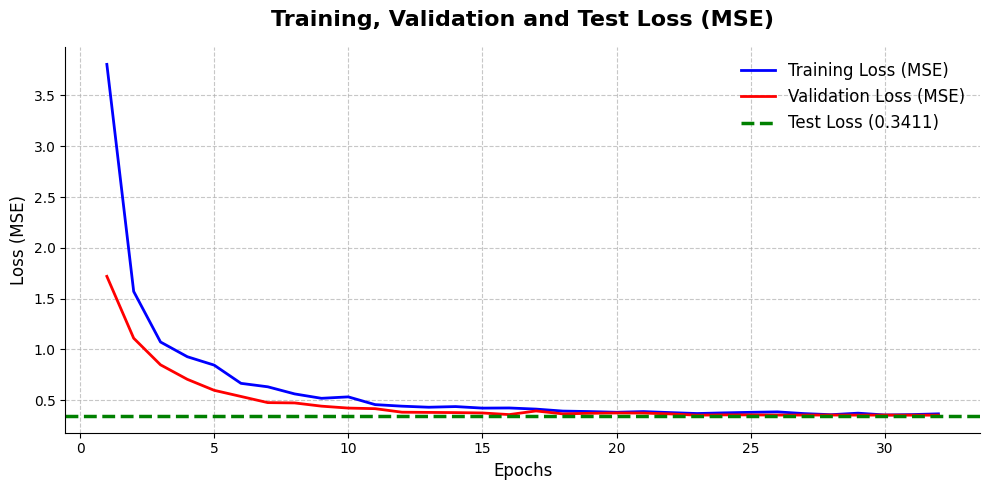

In [136]:
epochs = range(1, len(history_imp.history['loss']) + 1)
train_loss = history_imp.history['loss']
val_loss = history_imp.history['val_loss']

plt.figure(figsize=(10, 5))

plt.plot(epochs, train_loss, 'b-', label='Training Loss (MSE)', linewidth=2)
plt.plot(epochs, val_loss, 'r-', label='Validation Loss (MSE)', linewidth=2)
plt.axhline(y=test_loss, color='g', linestyle='--', label=f'Test Loss ({test_loss:.4f})', linewidth=2.5)

plt.title('Training, Validation and Test Loss (MSE)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.legend(frameon=False, fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

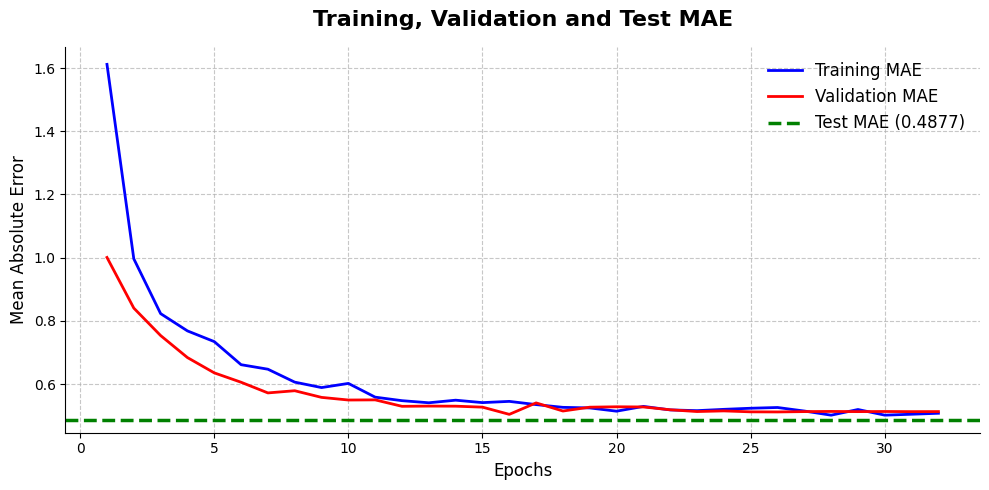

In [137]:
epochs = range(1, len(history_imp.history['mae']) + 1)
train_mae = history_imp.history['mae']
val_mae = history_imp.history['val_mae']

plt.figure(figsize=(10, 5))

plt.plot(epochs, train_mae, 'b-', label='Training MAE', linewidth=2)
plt.plot(epochs, val_mae, 'r-', label='Validation MAE', linewidth=2)
plt.axhline(y=test_mae, color='g', linestyle='--', label=f'Test MAE ({test_mae:.4f})', linewidth=2.5)

plt.title('Training, Validation and Test MAE', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Absolute Error', fontsize=12)
plt.legend(frameon=False, fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

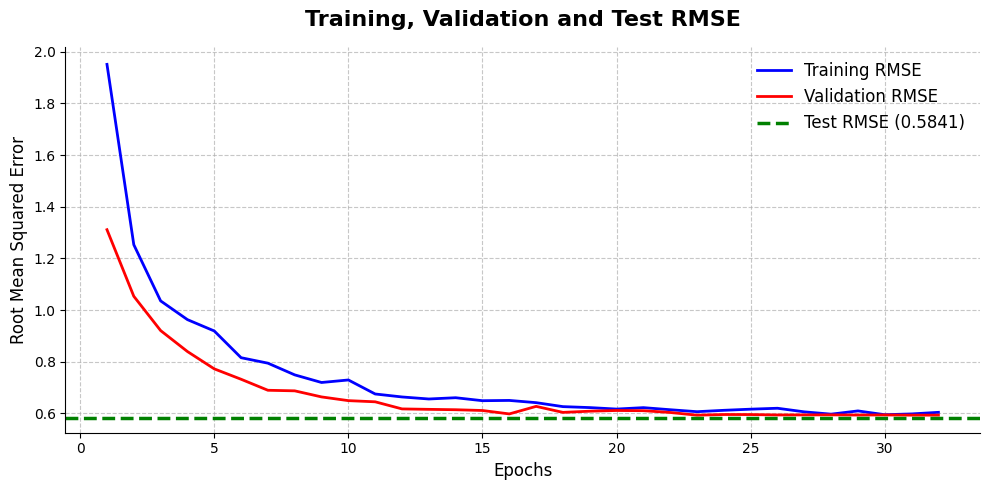

In [138]:
epochs = range(1, len(history_imp.history['rmse']) + 1)
train_rmse = history_imp.history['rmse']
val_rmse = history_imp.history['val_rmse']

plt.figure(figsize=(10, 5))

plt.plot(epochs, train_rmse, 'b-', label='Training RMSE', linewidth=2)
plt.plot(epochs, val_rmse, 'r-', label='Validation RMSE', linewidth=2)

plt.axhline(y=test_rmse, color='g', linestyle='--', label=f'Test RMSE ({test_rmse:.4f})', linewidth=2.5)

plt.title('Training, Validation and Test RMSE', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Root Mean Squared Error', fontsize=12)
plt.legend(frameon=False, fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [139]:
final_train_loss = history_imp.history['loss'][-1]
final_val_loss = history_imp.history['val_loss'][-1]

final_train_mae = history_imp.history['mae'][-1]
final_val_mae = history_imp.history['val_mae'][-1]

final_train_rmse = history_imp.history['rmse'][-1]
final_val_rmse = history_imp.history['val_rmse'][-1]

data = {
    'Métrica': ['MSE (Loss)', 'MAE', 'RMSE'],
    'Train': [final_train_loss, final_train_mae, final_train_rmse],
    'Validation': [final_val_loss, final_val_mae, final_val_rmse],
    'Test': [test_loss, test_mae, test_rmse]
}

df_metrics = pd.DataFrame(data).round(4)
df_metrics

,Métrica,Train,Validation,Test
0,MSE (Loss),0.3653,0.3523,0.3411
1,MAE,0.5078,0.5132,0.4877
2,RMSE,0.6044,0.5936,0.5841


In [140]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

mae_scores = []
rmse_scores = []
mejores_iteraciones = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_arr)):
    X_k_train, X_k_val = X_train_arr[train_idx], X_train_arr[val_idx]
    y_k_train, y_k_val = y_train_arr[train_idx], y_train_arr[val_idx]
    
    modelo_cv = xgb.XGBRegressor(
        n_estimators=500,           
        max_depth=4,                
        learning_rate=0.01,         
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=3,               
        random_state=42,
        early_stopping_rounds=30    
    )
    
    modelo_cv.fit(
        X_k_train, y_k_train,
        eval_set=[(X_k_val, y_k_val)],
        verbose=False 
    )
    
    preds = modelo_cv.predict(X_k_val)
    fold_mae = mean_absolute_error(y_k_val, preds)
    fold_rmse = mean_squared_error(y_k_val, preds)
    
    mae_scores.append(fold_mae)
    rmse_scores.append(fold_rmse)
    mejores_iteraciones.append(modelo_cv.best_iteration)
    
    print(f"Corte {fold + 1} | MAE: {fold_mae:.4f} | Árboles óptimos: {modelo_cv.best_iteration}")

arboles_promedio = int(np.mean(mejores_iteraciones))
print("-" * 40)
print(f"MAE Promedio en Validación: {np.mean(mae_scores):.4f}")
print(f"Árboles a utilizar para el modelo final: {arboles_promedio}")

Corte 1 | MAE: 0.4883 | Árboles óptimos: 3
Corte 2 | MAE: 0.4978 | Árboles óptimos: 5
Corte 3 | MAE: 0.5286 | Árboles óptimos: 4
Corte 4 | MAE: 0.4853 | Árboles óptimos: 22
Corte 5 | MAE: 0.5215 | Árboles óptimos: 42
----------------------------------------
MAE Promedio en Validación: 0.5043
Árboles a utilizar para el modelo final: 15


In [142]:
modelo_final = xgb.XGBRegressor(
    n_estimators=arboles_promedio, 
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=3,
    random_state=42
)

modelo_final.fit(X_train_arr, y_train_arr)

joblib.dump(modelo_final, "modelo_xgboost_final.pkl")

predicciones_test = modelo_final.predict(X_test_arr)

mae_final = mean_absolute_error(y_test_arr, predicciones_test)
mse_final = mean_squared_error(y_test_arr, predicciones_test)
rmse_final = np.sqrt(mean_squared_error(y_test_arr, predicciones_test))

print("--- RESULTADOS FINALES EN TEST CIEGO (XGBoost) ---")
print(f"MAE Final:  {mae_final:.4f}")
print(f"MSE Final: {mse_final:.4f}")
print(f"RMSE Final: {rmse_final:.4f}")

--- RESULTADOS FINALES EN TEST CIEGO (XGBoost) ---
MAE Final:  0.4864
MSE Final: 0.3268
RMSE Final: 0.5717
